# Table of contents

* **Introduction**
* **Objective**
* **Multi-Layer Perceptron (MLP) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Feature Engineering**
* **Model Training and Experiments**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial demonstrates how to build, train, and evaluate a Multi-Layer Perceptron (MLP) classifier using Scikit-Learn on a real-world malware detection dataset. The dataset consists of dynamic API call sequences extracted from executable files, represented as time-series features (t_0 to t_99), with a binary target label indicating whether a sample is benign (goodware) or malicious (malware).

An MLP is a type of feedforward artificial neural network that learns complex non-linear decision boundaries through multiple layers of interconnected nodes. It is particularly suitable for tabular data with high-dimensional feature interactions, making it a strong candidate for behavioral-based malware classification tasks.

# Objective

The primary objective of this tutorial is to:

- Implement a robust and well-tuned MLPClassifier from Scikit-Learn for binary classification of malware vs. benign samples.
- Demonstrate best practices in handling highly imbalanced datasets, feature scaling, dimensionality reduction, and class imbalance mitigation.
- Perform systematic hyperparameter tuning using Optuna to optimize model performance.
- Visualize learned decision boundaries in reduced-dimensional space and evaluate the model using multiple classification metrics.

# Multi-Layer Perceptron (MLP) Foundations

The Multi-Layer Perceptron ($\text{MLP}$), often referred to as a standard feedforward neural network, is a fundamental architecture in deep learning. Its core concept is the ability to learn complex, non-linear mappings between input data and output targets.

**The Universal Approximation Theorem**

The theoretical power of the $\text{MLP}$ is rooted in the Universal Approximation Theorem. This theorem states that a feedforward network with a single hidden layer and a non-linear activation function is theoretically capable of approximating any continuous function to an arbitrary level of accuracy, provided it has a sufficient number of neurons. This capability allows the $\text{MLP}$ to solve non-linearly separable problems, unlike simpler models such as the Perceptron.

**Learning Mechanism**

The $\text{MLP}$ learns through a two-step process:

- Forward Propagation: Input data moves through the network, from the input layer to the output layer, where a prediction is generated.
- Backpropagation: The error (the difference between the prediction and the true target) is calculated. This error is then propagated backward through the network, layer by layer. This process uses the chain rule of calculus to determine the gradient of the loss function with respect to every single weight in the network. These gradients indicate the direction and magnitude by which the weights must be adjusted.
- Optimization: An optimization algorithm (like $\text{SGD}$ or $\text{Adam}$) uses these gradients to update the weights, iteratively minimizing the overall error.

**MLP Composition and Structure**

The $\text{MLP}$ is organized into a minimum of three distinct types of layers:

**1. The Input Layer**

This layer receives the raw data features. It does not perform any computation; its nodes simply represent the input variables, passing the feature values directly to the next layer. The number of neurons in the input layer is always equal to the number of features in the dataset ($\mathbf{N_{features}}$).

**2. Hidden Layers**

These are the computational engine of the network, positioned between the input and output layers. A network is considered "deep" when it contains multiple hidden layers.

- Synaptic Connections (Weights): Each neuron in a hidden layer is connected to every neuron in the preceding layer. Each connection has an associated weight ($\mathbf{W}$), which is a trainable parameter that determines the strength of the connection.
- Bias: Each neuron also has a bias ($\mathbf{b}$), another trainable parameter that allows the activation function to be shifted, providing flexibility in the model's ability to fit the data.
- Activation Function: After the linear combination of weighted inputs and bias ($\mathbf{Z} = \mathbf{W} \cdot \mathbf{X} + \mathbf{b}$), the result is passed through a non-linear activation function (e.g., $\text{ReLU}$, $\text{Sigmoid}$, or $\text{Tanh}$). This non-linearity is essential for the $\text{MLP}$ to learn complex relationships and avoid simply collapsing into a linear model.

**3. The Output Layer**

This final layer produces the network's prediction. The number of neurons and the choice of activation function depend directly on the type of task:
- Binary Classification (e.g., malware vs. benign): Typically uses one neuron with a $\text{Sigmoid}$ activation, which outputs a probability between 0 and 1.
- Multi-class Classification (e.g., classifying images into 10 categories): Uses $N$ neurons (where $N$ is the number of classes) with a $\text{Softmax}$ activation, which converts the raw outputs into a probability distribution summing to 1.
- Regression (e.g., predicting house prices): Typically uses one neuron with no activation function (or a linear activation).

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">hash</td>
    <td class="tg-7zrl">Unique identifier for each record</td>
    <td class="tg-7zrl">Alphanumeric</td>
  </tr>
  <tr>
    <td class="tg-7zrl">t_0 - t_99</td>
    <td class="tg-7zrl">Time series measurement at index 0-99</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">malware</td>
    <td class="tg-7zrl">Goodware (0) and Malware (1)</td>
    <td class="tg-7zrl">Categorical (Class)</td>
  </tr>
</tbody>
</table>

**[Dataset Link](https://www.kaggle.com/datasets/ang3loliveira/malware-analysis-datasets-api-call-sequences)**

# Pipeline Overview

The end-to-end pipeline is structured sequentially, ensuring that each stage of data manipulation and model training is cleanly separated to prevent data leakage and maximize the model's ability to generalize:

- Data Preparation: Initial handling of identifier columns and missing values.
- Splitting and Scaling: Performing a stratified train-test split followed by feature standardization.
- Dimensionality and Imbalance Control: Applying Principal Component Analysis (PCA) for reduction and Synthetic Minority Over-sampling Technique (SMOTE) for balancing the training set.
- Model Training: Progressive training from a baseline model to an optimized model using Optuna for hyperparameter tuning.
- Evaluation: Comprehensive assessment using metrics and visualization tools suited for imbalanced classification.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing approach is essential for preparing the sequential API call data for the neural network and mitigating dataset challenges.
- Initial Cleanup and Splitting: Non-predictive identifier columns (e.g., hash) are removed. A stratified train-test split ($80%$-$20%$ ratio) is performed early to ensure the proportions of malware and benign samples are maintained in both sets, preventing information leakage by sequestering the test data immediately.
- Feature Scaling (StandardScaler): The StandardScaler transforms the features to a distribution with a zero mean and unit variance. This is a mandatory step for neural networks, as it prevents features with larger numerical ranges from dominating the gradient updates, thereby ensuring stable and fast convergence of the optimization algorithm.
- Dimensionality Reduction (PCA): PCA is applied to reduce the $100$ original features down to only $2$ principal components. This transformation serves two critical purposes:
    - it mitigates the curse of dimensionality and noise
    - it facilitates the visualization of decision boundaries in a $2D$ space.
- Class Imbalance Correction (SMOTE): The dataset is highly imbalanced toward the malware class. SMOTE is applied exclusively to the training set to generate synthetic minority class samples. This balances the class distribution ($50%$-$50%$) which prevents the MLP from developing a bias toward the majority class and improves the sensitivity (recall) to the minority class (benign samples).

**Model Training Approach**

The training methodology follows a structured path from establishing a baseline to achieving optimal performance through rigorous tuning.
- Baseline Establishment: Training commences with a default $\text{MLPClassifier}$ evaluated using $5$-fold stratified cross-validation. This provides a benchmark performance level against which all subsequent tuning efforts are measured.
- Optimizer Comparison: An empirical comparison is conducted across various solvers (optimization algorithms):
    - Stochastic Gradient Descent (SGD) variants, including those with momentum and Nesterov's momentum, are tested with varying learning rate schedules.
    - The Adam optimizer, known for its adaptive learning rate properties, is also evaluated. This step highlights the critical impact of the optimization method on the model's convergence path and final generalization ability.
- Hyperparameter Tuning (Optuna): Bayesian optimization using Optuna is employed for efficient hyperparameter search. The search space includes:
    - Network architecture (number and size of hidden layers, `hidden_layer_sizes`).
    - Activation functions ($\text{ReLU}$, $\text{tanh}$, $\text{logistic}$).
    - Regularization strength ($\alpha$) for $L2$ penalty.
    - Optimizer-specific parameters (`learning_rate, momentum`).
    - Early stopping is utilized during trials to restore the best weights, preventing overfitting and accelerating the search process.
- Final Model Refinement: The optimal configuration identified by Optuna is used to train the final model with an extended maximum iteration count to ensure full convergence, with early stopping remaining active as a robust defense against overfitting.

**Model Evaluation Approach**

Given the high-stakes nature of malware detection and the class imbalance, evaluation is comprehensive and relies on multiple metrics and diagnostic visualizations.
- Quantitative Metrics: The model's predictive performance is quantified using metrics specifically chosen for imbalanced classification:
    - Precision, Recall, and F1-score are calculated and macro-averaged to ensure performance on the minority class is given equal weight.
    - The Area Under the Receiver Operating Characteristic Curve ($\text{ROC-AUC}$) is used as a measure of the classifier's overall discriminative power across all possible threshold settings.
    - A full classification report and the confusion matrix provide detailed insights into false positives (benign marked as malware) and false negatives (malware marked as benign).
- Visual Diagnostics:
    - Precision-Recall curves and ROC curves are plotted to visually assess the model's performance independent of the chosen decision threshold.
    - Decision boundary plots are generated in the $2D$ PCA feature space for both the training and test sets. These visualizations are critical for understanding how the $\text{MLP}$ has learned to separate the two classes and whether the learned boundary generalizes effectively to the unseen test data.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install imblearn
!pip install imbalanced-learn==0.10.1
!pip install --upgrade imbalanced-learn

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl 
import seaborn as sns
import os
import warnings

from sklearn.utils import shuffle
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve
)
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    train_test_split
)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn import datasets 

from imblearn.over_sampling import SMOTE 

import optuna

%matplotlib inline

print(f"Optuna Version: {optuna.__version__}")

# Data Loading 

The analysis begins by reading the dataset, which contains $100$ sequential features (`t_0` to `t_99`) representing API calls and a final binary target column, malware.

In [ ]:
df = pd.read_csv('/kaggle/input/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv')
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


**Initial Data Cleaning**

- Identifier Removal: The hash column, which serves only as a unique identifier for the sample, is dropped. It provides no predictive value to the machine learning model and would introduce noise or potentially lead to model memorization.
- Missing Value Handling: The `pandas` function `dropna(how='any')` is applied. This implements a listwise deletion strategy, removing any sample (row) that contains at least one null value. This is a common, conservative approach when the dataset is large enough to afford the loss of a few samples, ensuring the model is only trained on complete sequences. The data check confirms no missing values remain.

In [3]:
df = df.drop(columns=['hash'],axis=1)
df = df.dropna(how='any')
df

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1,82,208,187,208,172,117,172,117,172,117,...,81,240,117,71,297,135,171,215,35,1
2,16,110,240,117,240,117,240,117,240,117,...,65,112,123,65,112,123,65,113,112,1
3,82,208,187,208,172,117,172,117,172,117,...,208,302,208,302,187,208,302,228,302,1
4,82,240,117,240,117,240,117,240,117,172,...,209,260,40,209,260,141,260,141,260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43871,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1
43872,82,240,117,240,117,240,117,240,117,172,...,159,224,82,159,224,82,159,224,82,1
43873,82,240,117,240,117,240,117,240,117,172,...,260,141,260,141,260,141,260,141,260,1
43874,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1


**Train and Test Split**

The processed data is split into training (80 percent) and testing (20 percent) sets using `train_test_split`. This procedure is essential for evaluating model performance:

- The training set is used to fit the model's parameters.
- The testing set is held back and used only once, at the very end, to provide an unbiased estimate of the model's generalization error on unseen data. This prevents data leakage and gives a realistic expectation of performance in a production environment.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (35100, 101)
test shape: (8776, 101)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

In [5]:
train.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
35602,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
13858,112,274,158,215,274,158,215,298,76,208,...,172,117,172,117,172,117,172,117,172,1
39770,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1024,208,286,76,110,240,117,208,187,208,198,...,286,240,286,117,208,286,240,286,117,1
31154,82,208,187,208,172,117,172,208,16,208,...,117,172,117,208,172,117,100,215,35,1


In [6]:
train.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,...,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000
mean,142.787123,211.254872,148.203333,188.834245,187.417949,174.108063,170.378148,199.045271,142.807322,167.325413,...,154.204786,173.156809,159.560484,164.906980,173.463419,152.373533,158.394758,160.395926,155.748262,0.975698
std,75.600839,60.294950,47.698712,68.358486,71.255625,65.739453,55.525942,65.516243,66.800136,53.441632,...,78.291792,82.742852,74.071577,70.322547,70.531624,79.906061,78.029384,75.022546,78.949398,0.153987
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,73.000000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,156.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,225.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35100 entries, 35602 to 15795
Columns: 101 entries, t_0 to malware
dtypes: int64(101)
memory usage: 27.3 MB


In [8]:
train.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

In [9]:
test.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

**Target Label Distribution**

The bar plot titled "Malware Distribution" visually confirms the numerical proportions. It shows a towering bar for the malware class ($\mathbf{1}$) and a minimal bar for the benign class ($\mathbf{0}$).

In [10]:
train['malware'].value_counts(normalize=True)*100

malware
1    97.569801
0     2.430199
Name: proportion, dtype: float64

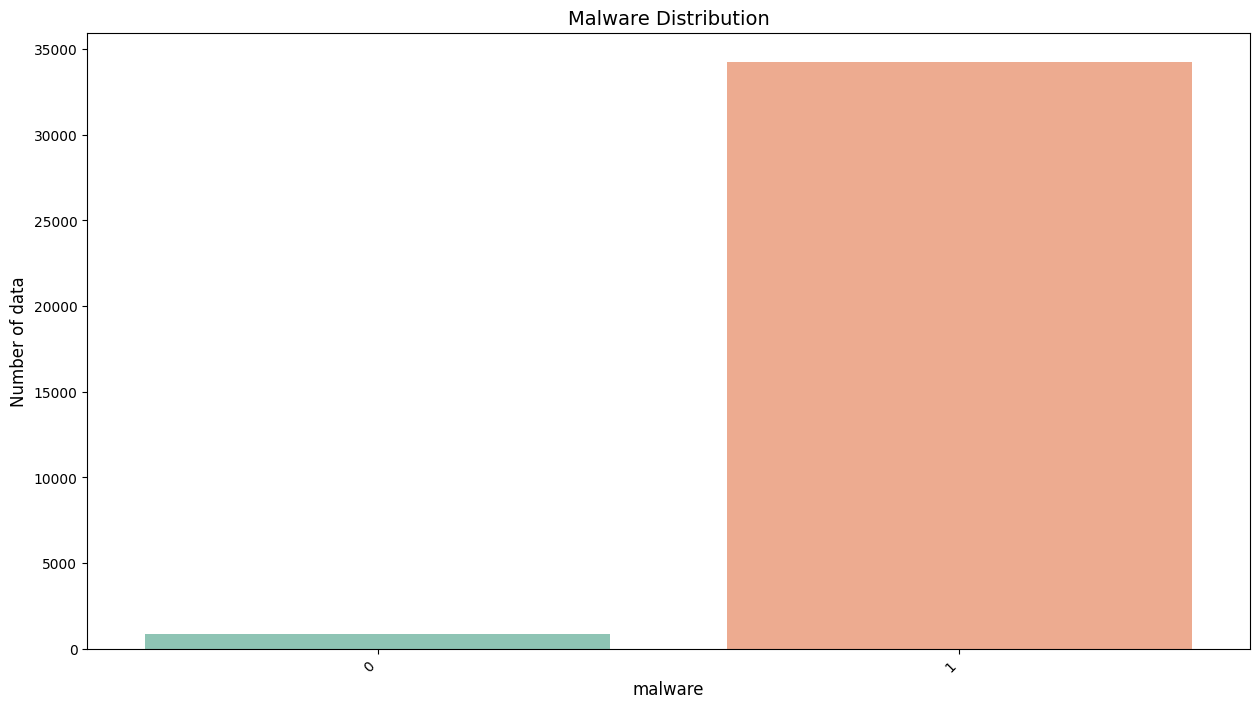

In [ ]:
cnt_pro = train['malware'].value_counts()

plt.figure(figsize=(15,8))
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel('Number of data', fontsize=12)
plt.xlabel('malware', fontsize=12)
plt.title('Malware Distribution', fontsize=14)
plt.show()

This distribution indicates a severe class imbalance.

- Impact on Modeling: A model trained directly on this data is highly susceptible to the accuracy paradox. The model could simply learn to predict the majority class ($\mathbf{1}$) for every sample and achieve an accuracy of 97.57 percent without actually learning any meaningful pattern to distinguish between the two classes.
- Required Mitigation: To successfully build a predictive model, future steps must include techniques to address this imbalance, such as oversampling the minority class (e.g., SMOTE), undersampling the majority class, or using cost-sensitive learning by adjusting class weights during model training. The choice of evaluation metrics must also shift away from simple accuracy to metrics like $\text{F1}$-score, $\text{Precision}$, and $\text{Recall}$.

# Feature Engineering

**Features and Target Labels Split**

The first step in preparing the data for supervised learning is to explicitly separate the feature set ($\mathbf{X}$) from the target variable ($\mathbf{y}$). The $\mathbf{100}$ $\text{API}$ call columns (`t_0` through `t_99`) are designated as the input features (`x_train` and `x_test`), while the malware column, containing the binary classification labels, is designated as the output (`y_train` and `y_test`). This structured separation is crucial for model training.

In [ ]:
x_train = train.drop('malware', axis=1) 
y_train = train['malware'] 
x_test = test.drop('malware', axis=1) 
y_test = test['malware'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35100, 100)
y_train shape: (35100,)
X_test shape: (8776, 100)
y_test shape: (8776,)


**Data Normalization (Standardization)**

Standardization is applied using the `StandardScaler` to ensure that all features contribute equally to the distance calculations and gradient updates during model training. The concept is to transform the data such that each feature column has a mean of zero ($\approx 0$) and a standard deviation of one ($\approx 1$).

- Fitting on Training Data: The `StandardScaler` is fit only on the training set (`x_train`). This step calculates the mean and standard deviation parameters from the training data alone.
- Transformation: These calculated parameters are then used to transform both the training set (`x_train_std`) and the test set (`x_test_std`). Transforming the test set using the training set's parameters prevents data leakage, ensuring the test set remains truly unseen.

In [ ]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [ ]:
x_train_std = pd.DataFrame(x_train_std, columns=x_train.columns)
x_test_std = pd.DataFrame(x_test_std, columns=x_test.columns)
x_train_std.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
count,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,...,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04
mean,-1.530400e-16,-1.220676e-16,-2.702492e-16,-1.805710e-16,-1.781418e-17,-6.498126e-17,7.530538e-17,8.502221e-18,-1.064802e-16,2.206529e-17,...,3.623566e-17,1.651860e-16,2.753100e-17,-1.615422e-16,1.595179e-16,2.200456e-16,1.388696e-16,1.046583e-16,2.672127e-17,-2.186285e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.862269e+00,-3.470570e+00,-3.065186e+00,-2.733193e+00,-2.630257e+00,-2.648494e+00,-3.068486e+00,-3.007622e+00,-2.137860e+00,-3.093614e+00,...,-1.988217e+00,-1.969644e+00,-2.092740e+00,-2.154170e+00,-2.345042e+00,-2.459406e+00,-1.906935e+00,-2.029966e+00,-2.138000e+00,-1.972789e+00
25%,-8.040650e-01,-6.510567e-01,-6.541849e-01,-1.050861e+00,-9.882581e-01,-8.687154e-01,-9.613328e-01,-6.112353e-01,-3.863419e-01,-9.417027e-01,...,-5.210352e-01,-9.350384e-01,-6.787004e-01,-6.150960e-01,-6.812561e-01,-8.005519e-01,-7.931117e-01,-7.483795e-01,-6.984123e-01,-1.048133e+00
50%,-8.040650e-01,4.767487e-01,2.053893e-01,3.827780e-01,-2.163783e-01,-2.450323e-01,2.920932e-02,2.435267e-01,-3.863419e-01,8.747213e-02,...,-6.894509e-03,-1.686636e-01,-1.398097e-02,-2.505786e-01,8.664514e-02,-2.074870e-02,-1.423383e-01,1.615471e-01,-5.859557e-02,-1.868092e-01
75%,9.551998e-01,4.767487e-01,4.989025e-01,7.485023e-01,1.215108e+00,1.002334e+00,8.036331e-01,6.251169e-01,9.759502e-01,7.611139e-01,...,1.021387e+00,1.095855e+00,1.049570e+00,1.085986e+00,7.123424e-01,9.433716e-01,7.837623e-01,8.407881e-01,8.611411e-01,8.771786e-01
max,2.158907e+00,1.571383e+00,3.308243e+00,1.714014e+00,1.664202e+00,2.006311e+00,2.442530e+00,1.632515e+00,2.443034e+00,2.594916e+00,...,1.849028e+00,1.938867e+00,1.605517e+00,1.977028e+00,2.006398e+00,1.879135e+00,1.922616e+00,1.891689e+00,1.940832e+00,1.903167e+00


**Dimensionality Reduction (PCA)**

The dataset contains $\mathbf{100}$ sequential $\text{API}$ calls. $\text{PCA}$ is an unsupervised technique used to linearly transform the data into a lower-dimensional subspace while retaining as much of the original data's variance as possible. This process addresses the curse of dimensionality by compressing redundant or correlated features. In this process, the data is reduced to only two principal components (`n_components=2`).

- Principal Components ($\mathbf{PC1}$ and $\mathbf{PC2}$): These new components are orthogonal (uncorrelated) and are ordered by the amount of variance they explain. $\mathbf{PC1}$ captures the largest amount of variance, and $\mathbf{PC2}$ captures the second largest.
- Benefit: Reducing the dimensions to two allows for easy, visual inspection of the dataset's structure and separability.

In [ ]:
pca = PCA(n_components=2)

x_train = pca.fit_transform(x_train_std)
x_test = pca.transform(x_test_std)

**Before Oversampling Visualization**

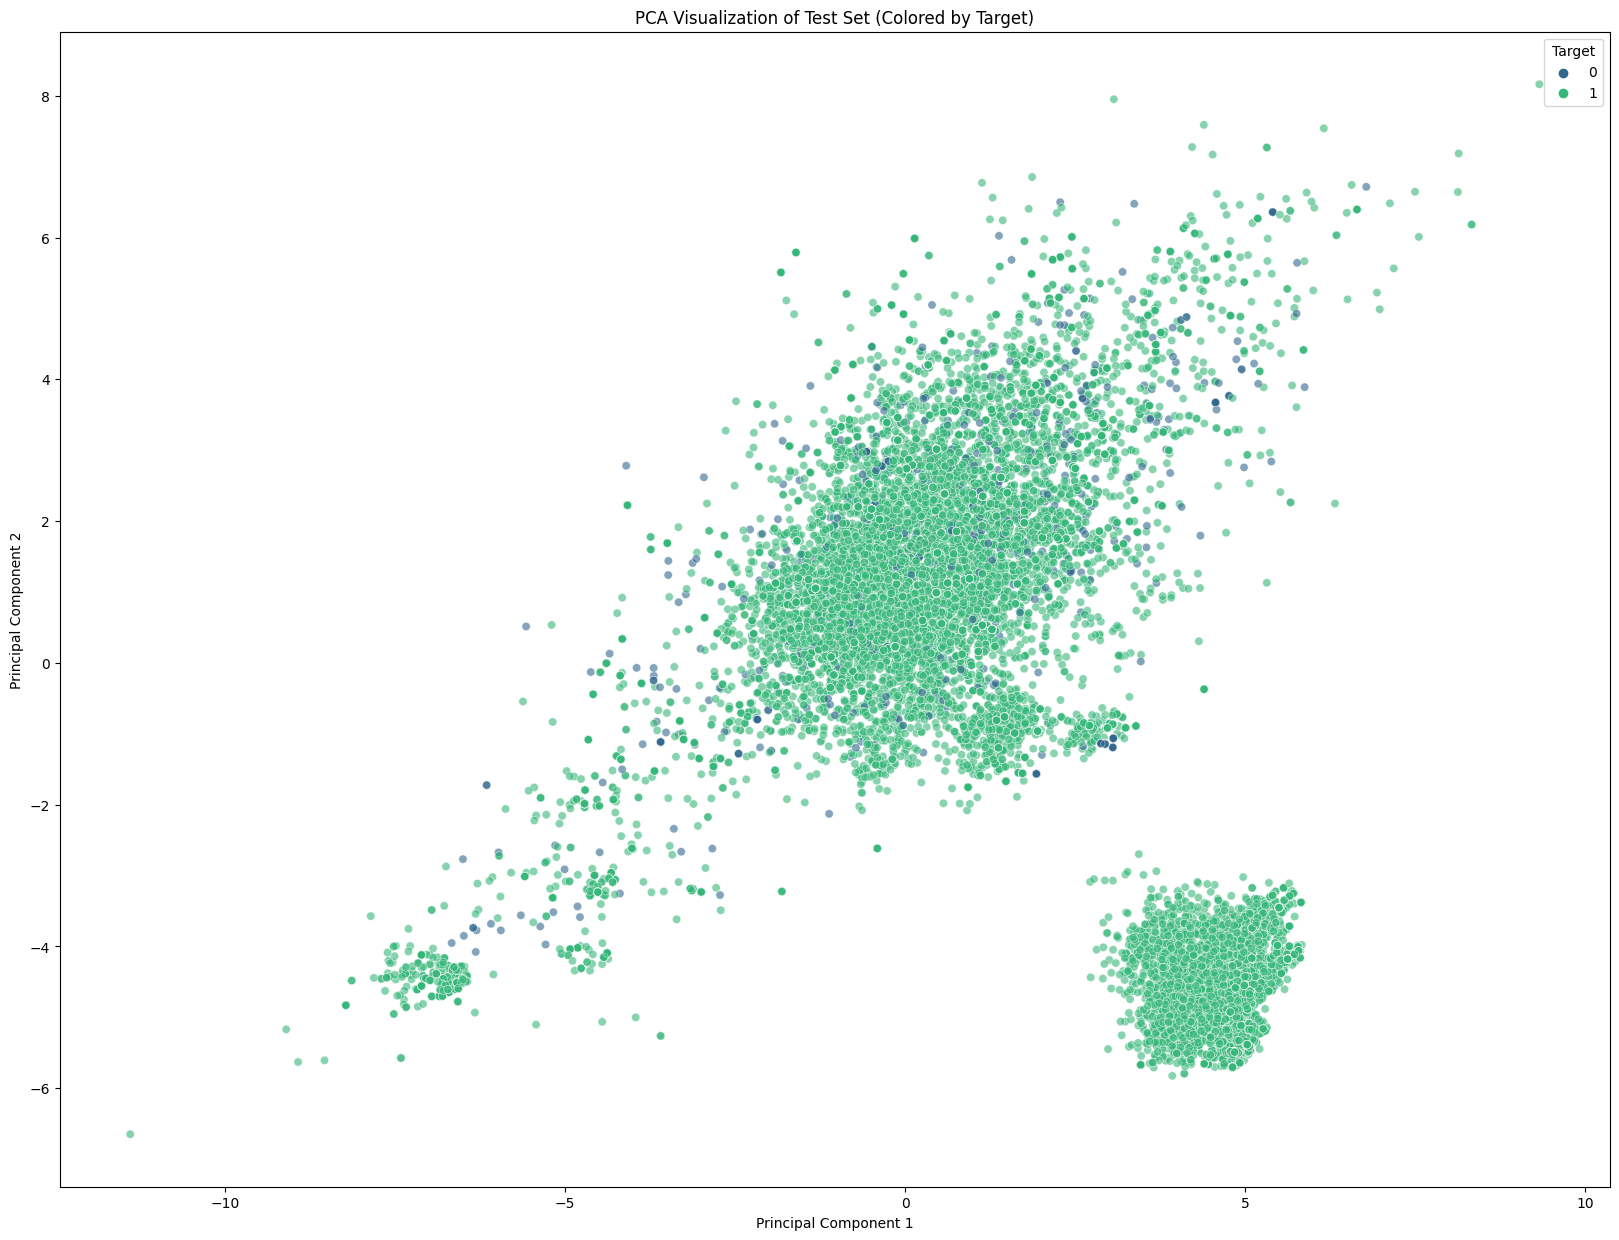

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0], 
    'PC2': x_train[:, 1], 
    'Target': y_train    
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",  
    palette="viridis",  
    alpha=0.6  
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

# Show the plot
plt.show()

**Visualization Interpretation (Before Oversampling)**

The scatter plot of the data after $\text{PCA}$ reduction shows the projection of the `x_train` data onto the $\mathbf{PC1}$ and $\mathbf{PC2}$ plane.

- Dominance of One Class: The plot is dominated by a single, dense cluster of points, corresponding to the majority class (Malware, $\mathbf{1}$).
- Lack of Separation: The minority class (Benign, $\mathbf{0}$) points are barely visible, scattered sparsely within the main cluster.

In this two-dimensional space, the two classes are not linearly separable. The visual overlap indicates that any classifier relying only on these two principal components would struggle to effectively distinguish between the benign and malware samples due to the overwhelming class imbalance and feature entanglement.

**Oversampling (SMOTE)**

Due to the severe class imbalance identified earlier, the Synthetic Minority Over-sampling Technique ($\text{SMOTE}$) is applied. $\text{SMOTE}$ works by synthetically generating new minority class samples in the feature space. It identifies neighbors for each minority instance and creates new, synthetic instances along the line segments connecting the minority instance to its neighbors. The goal is to balance the class distribution, achieving a $50%$ / $50%$ split between the two classes.

In [ ]:
smote = SMOTE(random_state=42)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
x_train, y_train = smote.fit_resample(x_train, y_train)

print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)
y_train.value_counts(normalize=True)*100

Shape of original x_train: (35100, 2)
Shape of original y_train: (35100,)
Shape of original x_train: (68494, 2)
Shape of original y_train: (68494,)


malware
1    50.0
0    50.0
Name: proportion, dtype: float64

The `x_train` dataset size increases from $\mathbf{35,100}$ to $\mathbf{68,494}$ samples, with both the benign ($\mathbf{0}$) and malware ($\mathbf{1}$) classes now representing exactly 50 percent of the training data. The model is now ready for training without a strong bias toward the majority class.

**After Oversampling Visualization**

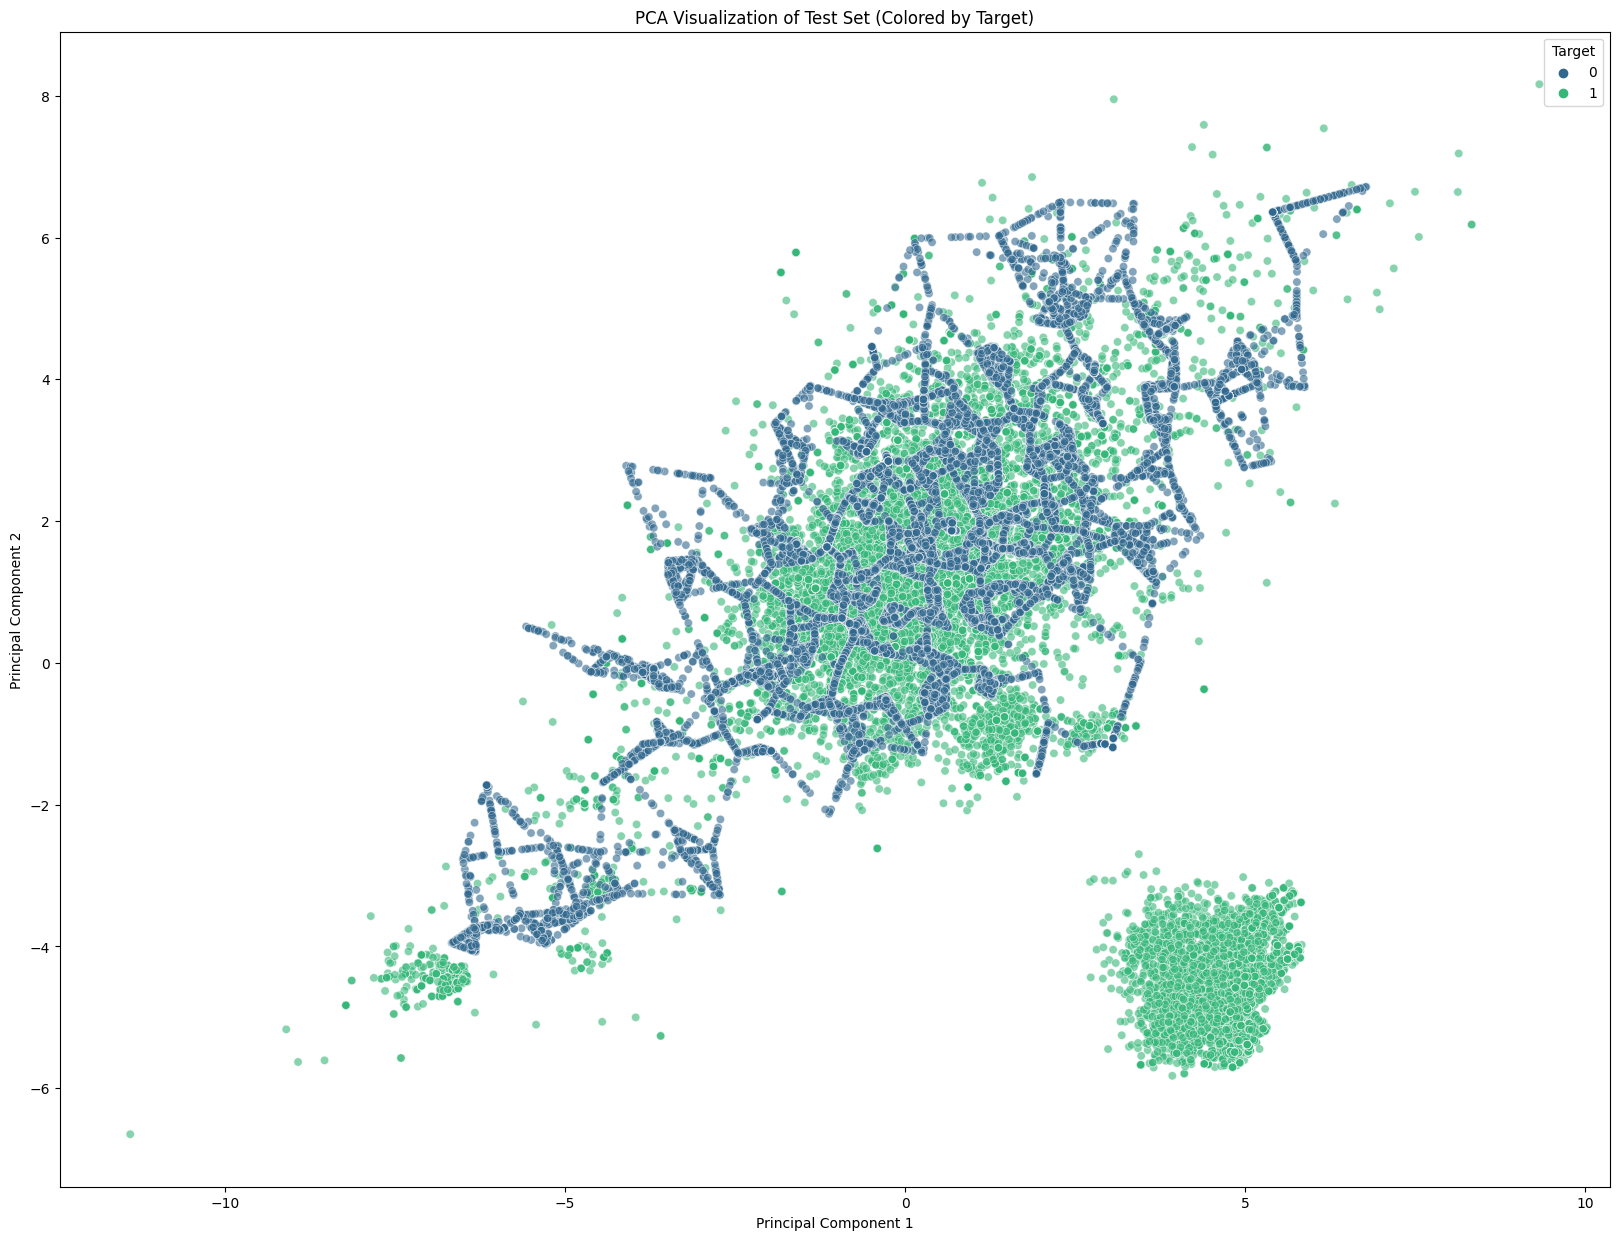

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],  
    'PC2': x_train[:, 1],  
    'Target': y_train        
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",  
    palette="viridis",  
    alpha=0.6 
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Visualization Interpretation (After Oversampling)**

The scatter plot after $\text{SMOTE}$ shows a fundamental change in the data distribution.

- Synthetic Population: The minority class ($\mathbf{0}$) now has a visibly significant presence. The synthetic samples have been created, filling the areas surrounding the original minority points.
- Density: The two classes now appear equally dense in the $\text{PC}$ space, reflecting the $50%$ / $50%$ ratio.
- Separability Status: While the synthetic samples make the minority class visible, the data remains highly intertwined. The two classes still do not form two distinct, separate clusters. This suggests that even after balancing, a successful classifier will require non-linear decision boundaries or access to the full $\mathbf{100}$-dimensional feature set, rather than relying solely on the compressed $\text{PCA}$ features.

# Model Training and Experiments

**MLP in Scikit-Learn**

The Multi-Layer Perceptron ($\text{MLP}$) in Scikit-Learn is provided through the class `MLPClassifier` (for classification tasks) and `MLPRegressor` (for regression tasks). While Scikit-Learn focuses on ease of use and integrates well with its ecosystem, its $\text{MLP}$ implementation is generally designed for modest-sized networks and datasets, unlike dedicated deep learning libraries (like TensorFlow or PyTorch).

**MLPClassifier**

The `MLPClassifier` implements a standard feedforward neural network that trains using Backpropagation and an optimization algorithm (like $\text{SGD}$ or $\text{Adam}$). The key difference from highly flexible libraries is that Scikit-Learn abstracts away the complexities of custom layers and activation functions, providing a parameter-driven approach.

**Cross-Validation**

Model performance is initially assessed using Stratified K-Fold Cross-Validation (`cv=5`). This technique partitions the training data into five equally sized folds. The model is trained and validated five times, with each fold serving as the validation set exactly once.
- Stratification: Since the data was originally imbalanced, stratification ensures that the class distribution (the $50%$ / $50%$ balance achieved by $\text{SMOTE}$) is maintained within each fold.

In [ ]:
ml_models = [
    ("MLPClassifier", MLPClassifier(random_state=42)) 
]

for model_name, model in ml_models:
    print(f"{model_name}: ")
    model.fit(x_train, y_train)  
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy') 
    print("\tStratified K-Fold Cross-Validation Scores:", cv_scores)
    print('-' * 100)
    print(f'\tAverage Stratified K-Fold Cross-Validation Score: {cv_scores.mean():.4f}')
    print('-' * 100)

MLPClassifier: 


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

	Stratified K-Fold Cross-Validation Scores: [0.78494781 0.77881597 0.79312359 0.79151763 0.78639217]
----------------------------------------------------------------------------------------------------
	Average Stratified K-Fold Cross-Validation Score: 0.7870
----------------------------------------------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


**Result**

The average cross-validation accuracy score achieved by the default $\text{MLPClassifier}$ is $\mathbf{0.7870}$. This suggests a moderate ability to generalize on the balanced training data.

**Convergence Warning**

Throughout the cross-validation process, a ConvergenceWarning is repeatedly raised. This indicates that the iterative optimization process (which adjusts the network's weights to minimize loss) failed to reach the specified tolerance within the maximum allowed number of iterations ($\mathbf{200}$). The network stopped training before the objective function fully converged, suggesting that more epochs (`max_iter`) might be necessary, or the initial learning rate could be inappropriate.

**Optimization Algorithm Experiments**

**Experiment Rationale**

The second part of the analysis investigates how different optimization algorithms and learning rate schedules affect the convergence and final performance of the $\text{MLP}$. Experiments inspects training performance of a Multi-layer Perceptron (MLP) Classifier using different optimization algorithms and learning rate schedules. The optimizer's role is critical as it determines how the model traverses the loss function landscape. This analysis explores and visualizes the training loss curves—charts showing how a model’s error decreases over time—for various stochastic optimizers, including $\text{SGD}$ (Stochastic Gradient Descent) and $\text{Adam}$.Due to constraints on time or computational resources, the study utilizes several small datasets. The experiments will illustrate the $\text{MLP}$ on four standard toy datasets ($\text{iris}$, $\text{digits}$, $\text{circles}$, $\text{moons}$). For these smaller problems, the $\text{L-BFGS}$ optimization algorithm is often a more efficient choice, although it wasn't the focus here.Importantly, the general performance patterns observed with these optimizers on small datasets are typically transferable to larger datasets. A key finding is that all of these results are highly sensitive to the initial value chosen for the learning rate (learning_rate_init).

**Optimization Concepts Tested**

- Stochastic Gradient Descent ($\text{SGD}$): This fundamental optimizer updates weights based on the gradient of the loss function.
    - Constant Learning Rate: Uses a fixed step size.
    - Inverse Scaling Learning Rate: The step size decreases over time (`learning_rate` $\propto 1$ / $\text{t}$), aiding fine-tuning toward the end of training.
- Momentum: This technique accelerates $\text{SGD}$ in the relevant direction and dampens oscillations by incorporating a fraction of the past update vector into the current update.
- Nesterov's Momentum: A slight modification to momentum that computes the gradient not at the current position, but at the position the momentum term suggests the parameters will be. This provides a lookahead that can lead to faster and more stable convergence.
- Adam: An adaptive learning rate algorithm that computes individual learning rates for different parameters. It combines the benefits of $\text{Momentum}$ and $\text{RMSProp}$ (Root Mean Square Propagation).


learning on dataset iris
training: constant learning-rate
Training set score: 0.980000
Training set loss: 0.096950
training: constant with momentum
Training set score: 0.980000
Training set loss: 0.049530
training: constant with Nesterov's momentum
Training set score: 0.980000
Training set loss: 0.049540
training: inv-scaling learning-rate
Training set score: 0.360000
Training set loss: 0.978444
training: inv-scaling with momentum
Training set score: 0.860000
Training set loss: 0.504185
training: inv-scaling with Nesterov's momentum
Training set score: 0.860000
Training set loss: 0.503452
training: adam
Training set score: 0.980000
Training set loss: 0.045311

learning on dataset digits
training: constant learning-rate
Training set score: 0.956038
Training set loss: 0.243802
training: constant with momentum
Training set score: 0.992766
Training set loss: 0.041297
training: constant with Nesterov's momentum
Training set score: 0.993879
Training set loss: 0.042898
training: inv-scaling 

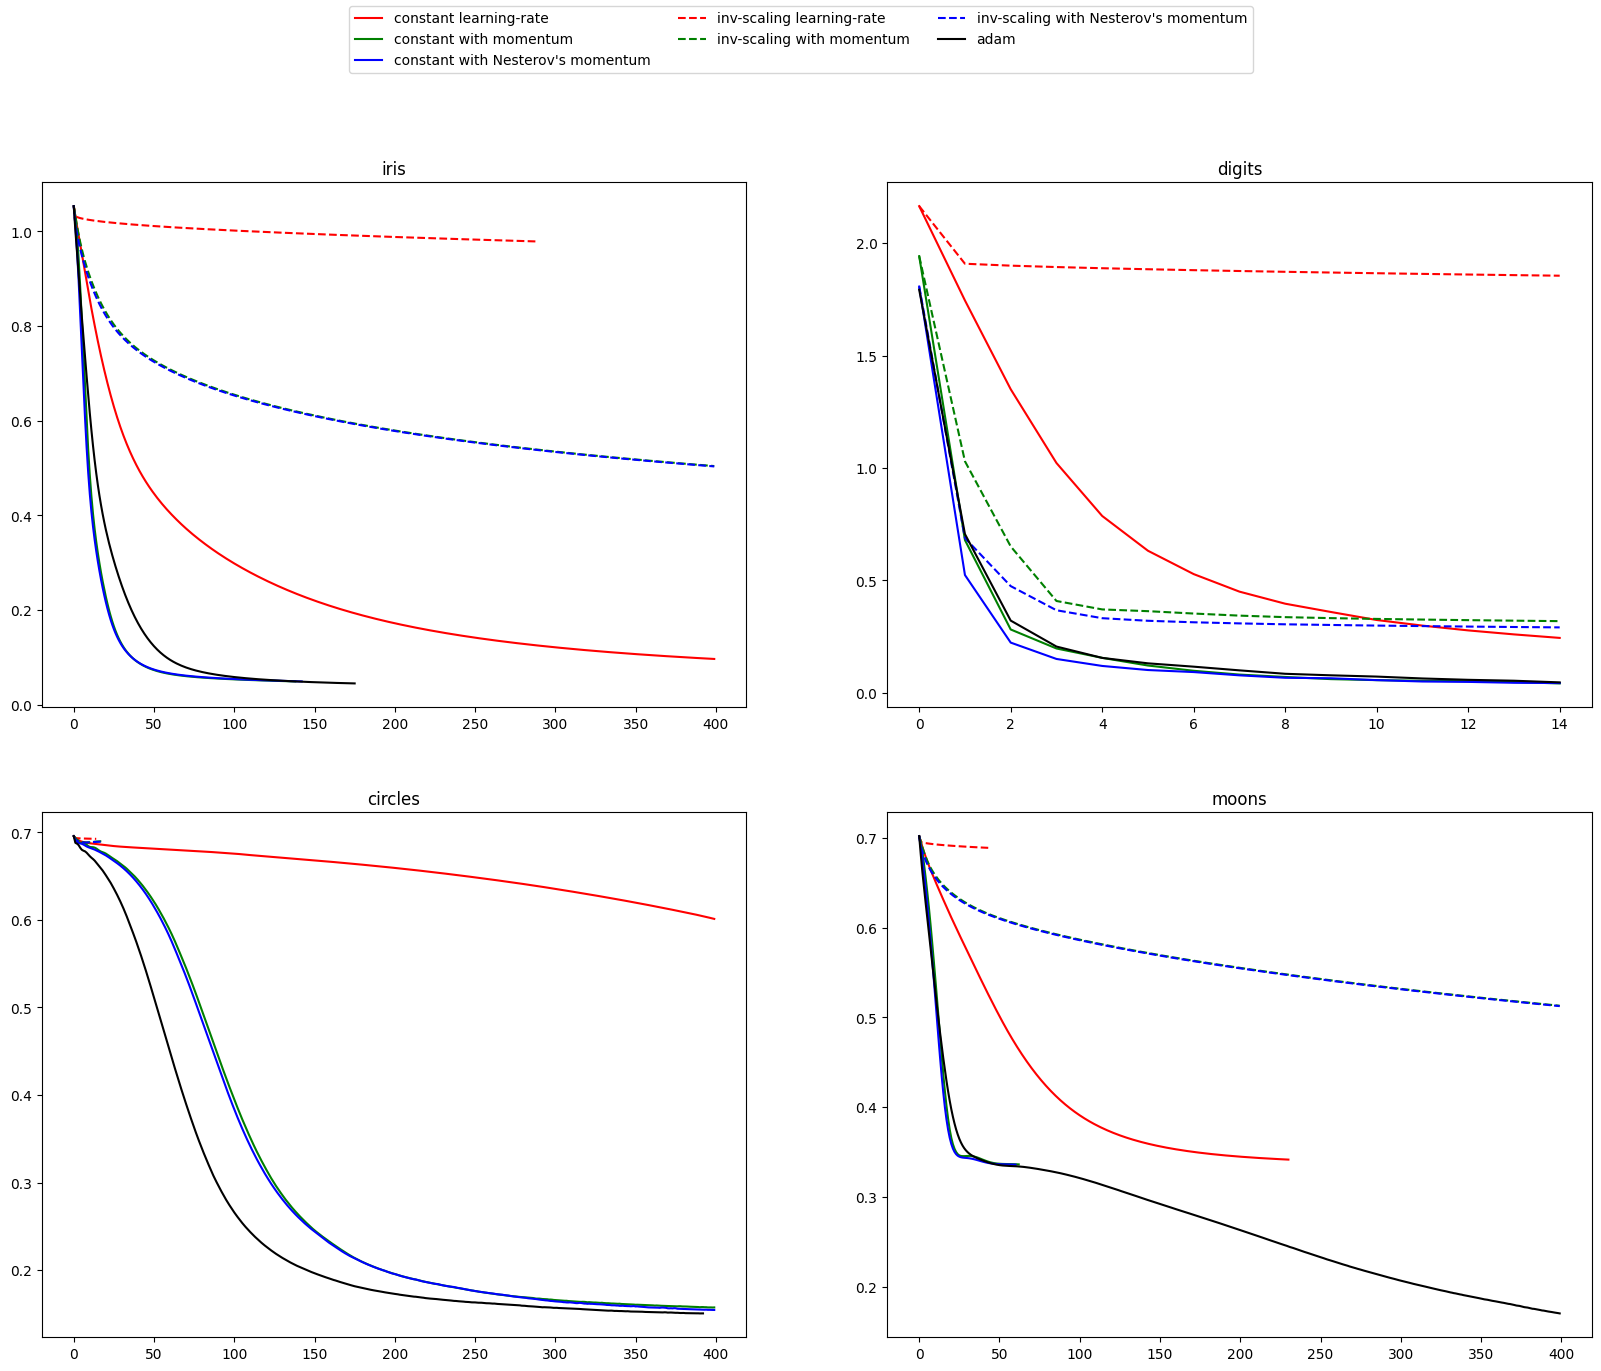

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

# different learning rate schedules and momentum parameters
params = [
    {
        "solver": "sgd",
        "learning_rate": "constant",
        "momentum": 0,
        "learning_rate_init": 0.2,
    },
    {
        "solver": "sgd",
        "learning_rate": "constant",
        "momentum": 0.9,
        "nesterovs_momentum": False,
        "learning_rate_init": 0.2,
    },
    {
        "solver": "sgd",
        "learning_rate": "constant",
        "momentum": 0.9,
        "nesterovs_momentum": True,
        "learning_rate_init": 0.2,
    },
    {
        "solver": "sgd",
        "learning_rate": "invscaling",
        "momentum": 0,
        "learning_rate_init": 0.2,
    },
    {
        "solver": "sgd",
        "learning_rate": "invscaling",
        "momentum": 0.9,
        "nesterovs_momentum": False,
        "learning_rate_init": 0.2,
    },
    {
        "solver": "sgd",
        "learning_rate": "invscaling",
        "momentum": 0.9,
        "nesterovs_momentum": True,
        "learning_rate_init": 0.2,
    },
    {"solver": "adam", "learning_rate_init": 0.01},
]

labels = [
    "constant learning-rate",
    "constant with momentum",
    "constant with Nesterov's momentum",
    "inv-scaling learning-rate",
    "inv-scaling with momentum",
    "inv-scaling with Nesterov's momentum",
    "adam",
]

plot_args = [
    {"c": "red", "linestyle": "-"},
    {"c": "green", "linestyle": "-"},
    {"c": "blue", "linestyle": "-"},
    {"c": "red", "linestyle": "--"},
    {"c": "green", "linestyle": "--"},
    {"c": "blue", "linestyle": "--"},
    {"c": "black", "linestyle": "-"},
]

def plot_on_dataset(x_train, y_train, ax, name):
    # for each dataset, plot learning for each learning strategy
    print("\nlearning on dataset %s" % name)
    ax.set_title(name)

    x_train = MinMaxScaler().fit_transform(x_train)
    mlps = []
    if name == "digits":
        # digits is larger but converges fairly quickly
        max_iter = 15
    else:
        max_iter = 400

    for label, param in zip(labels, params):
        print("training: %s" % label)
        mlp = MLPClassifier(random_state=0, max_iter=max_iter, **param)

        # some parameter combinations will not converge as can be seen on the
        # plots so they are ignored here
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=ConvergenceWarning, module="sklearn"
            )
            mlp.fit(x_train, y_train)

        mlps.append(mlp)
        print("Training set score: %f" % mlp.score(x_train, y_train))
        print("Training set loss: %f" % mlp.loss_)
    for mlp, label, args in zip(mlps, labels, plot_args):
        ax.plot(mlp.loss_curve_, label=label, **args)

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
# load / generate some toy datasets
iris = datasets.load_iris()
x_train_digits, y_train_digits = datasets.load_digits(return_X_y=True)
data_sets = [
    (iris.data, iris.target),
    (x_train_digits, y_train_digits),
    datasets.make_circles(noise=0.2, factor=0.5, random_state=1),
    datasets.make_moons(noise=0.3, random_state=0),
]

for ax, data, name in zip(
    axes.ravel(), data_sets, ["iris", "digits", "circles", "moons"]
):
    plot_on_dataset(*data, ax=ax, name=name)

fig.legend(ax.get_lines(), labels, ncol=3, loc="upper center")
plt.show()

**Visualization Interpretation**

The plots illustrate the loss curve (training loss over iterations) for the $\text{MLP}$ on four standard toy datasets ($\text{iris}$, $\text{digits}$, $\text{circles}$, $\text{moons}$).

- Superiority of Adam and Momentum: On all datasets, the $\mathbf{Adam}$ optimizer and $\mathbf{SGD}$ with $\mathbf{Momentum}$ (both constant and Nesterov's) consistently achieve the lowest final training loss and the fastest convergence rate (steepest initial drop). This validates their efficacy in navigating complex loss landscapes.
- Poor Performance of Inverse Scaling without Momentum: $\text{SGD}$ with an inverse scaling learning rate, particularly without momentum, struggles significantly. It often exhibits a very slow loss reduction (as seen in the $\text{digits}$ plot) or fails to escape local minima entirely, resulting in high final loss and low training accuracy (e.g., $\text{circles}$ and $\text{moons}$ datasets).

The experiments confirm that for deep learning tasks involving $\text{MLP}$ or similar networks, adaptive methods like Adam or accelerated methods like $\mathbf{SGD}$ with Momentum are the most effective optimization strategies for achieving rapid convergence and superior final performance. The initial malware training step should adopt one of these optimized settings to address the convergence issue.

**Hyperparameter Tuning (Optuna)**

**Architectural Hyperparameters**

These settings define the physical structure of the network:

- `hidden_layer_sizes`: This is a tuple that specifies the size and number of the hidden layers. The length of the tuple determines the number of hidden layers, and each integer in the tuple dictates the number of neurons within that specific layer. For instance, (`100, 50`) creates a network with two hidden layers: the first has 100 neurons, and the second has 50.
- `activation`: This parameter determines the non-linear function applied within each hidden neuron. This non-linearity is what allows the $\text{MLP}$ to learn complex relationships and is essential for moving beyond simple linear models. Options include $\mathbf{'relu'}$ (Rectified Linear Unit), $\mathbf{'tanh'}$ (Hyperbolic Tangent), and $\mathbf{'logistic'}$ (Sigmoid).

**Optimization and Training Hyperparameters**

These control the mechanism the $\text{MLP}$ uses to find the best possible set of weights:

- `solver`: This specifies the optimization algorithm used to update the weights based on the calculated error gradients. The default is $\mathbf{'adam'}$, an adaptive algorithm that is typically fast and robust. Other options include $\mathbf{'sgd'}$ (Stochastic Gradient Descent) and $\mathbf{'lbfgs'}$ (often better for smaller datasets).
- `learning_rate_init`: This sets the starting step size for the optimizer. It controls how much the weights are adjusted in response to the estimated error. A high initial rate risks overshooting the optimal solution, while a low rate can make training excessively slow.
- `max_iter`: This is the maximum number of epochs (full passes over the training data) the network will train for. It acts as a hard limit on training time. If the optimization process fails to converge within this limit, the classifier raises a $\text{ConvergenceWarning}$.
- `batch_size`: This defines the number of samples used in one forward/backward pass before the model's weights are updated. Smaller batches introduce more randomness but can help avoid sharp local minima, whereas larger batches provide a more stable, but slower, gradient estimate.
- `momentum`: Used specifically with the $\mathbf{'sgd'}$ solver, this parameter helps accelerate the optimizer in consistent directions and dampens oscillations by incorporating a fraction of the previous weight update into the current one.
- `nesterovs_momentum`: A slight refinement of standard momentum. When set to $\text{True}$, it provides a "lookahead" feature, often leading to faster and more efficient convergence.

**Regularization and Stopping Hyperparameters**

These help prevent the network from overfitting the training data:alpha: This is the regularization strength parameter, often referred to as L2 regularization or weight decay. By increasing $\alpha$, the model is penalized for having large weights, forcing it to use simpler and smoother decision boundaries, which improves generalization to unseen data.
- `tol`: This is the tolerance for the optimization. Training stops early if the loss function's improvement falls below this small threshold over a specified number of consecutive iterations.
- `early_stopping`: When set to $\text{True}$, this mechanism monitors a score on a held-out validation set. If the score does not improve for a set number of iterations (defined by `n_iter_no_change`), training is halted, preventing the model from overfitting the training data.

**Optuna for MLPClassifier**

This approach employs Optuna, an automatic hyperparameter optimization framework, to systematically search for the optimal settings for a Scikit-Learn Multi-Layer Perceptron Classifier ($\text{MLPClassifier}$). The goal is to maximize the model's accuracy, which is used as the objective function.

The process of hyperparameter tuning is essential because the architecture and training dynamics of a neural network are highly sensitive to these external settings.

- Objective Function: The objective function acts as the core of the tuning process. For each trial, it receives a suggested set of hyperparameters from Optuna, uses them to initialize the $\text{MLPClassifier}$, trains the model on the data (presumed to be $\text{PCA}$-transformed training data), and returns a single metric (in this case, the training accuracy). Optuna attempts to maximize this returned value.
- Hyperparameter Search Space: The approach defines a specific range of values for Optuna to explore for critical hyperparameters:
    - Architecture (`hidden_layer_sizes`): Different combinations of two-layer and single-layer networks are tested, such as $\mathbf{(50, 50)}$ and $\mathbf{(100, 50)}$, directly controlling the network's capacity.
    - Non-linearity (`activation`): The choices ($\mathbf{'relu'}$, $\mathbf{'tanh'}$, $\mathbf{'logistic'}$) determine how the network processes and transforms information between layers.
    - Regularization (`alpha`): This is the $\mathbf{L2}$ penalty strength, tuned on a logarithmic scale ($\mathbf{10^{-5}}$ to $\mathbf{10^{-2}}$), which penalizes large weights to prevent overfitting.
    - Optimization (`solver`): The tuning compares the performance of the adaptive Adam solver against the classic Stochastic Gradient Descent ($\text{SGD}$).
    - Learning Rate (`learning_rate_init`): The initial step size is critical and is tuned on a logarithmic scale, allowing the search to quickly test very small and large values.
    - $\text{SGD}$-Specific Parameters: If the $\text{SGD}$ solver is selected, the parameters momentum and `nesterovs_momentum` are included in the search to accelerate and stabilize the descent process.
- Training Strategy: To manage time and prevent resource waste, `early_stopping` is enabled for all trials. This technique monitors the performance on a validation subset and stops training if the loss does not improve substantially over 10 consecutive epochs, thus focusing computational effort on more promising hyperparameter sets.

In [ ]:
def objective(trial):
    hidden_layer_sizes_str = trial.suggest_categorical(
        "hidden_layer_sizes", ["(50,)", "(100,)", "(50, 50)", "(100, 50)"]
    )
    hidden_layer_sizes = eval(hidden_layer_sizes_str)

    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)

    if solver == "sgd":
        learning_rate_init = trial.suggest_float("learning_rate_init", 1e-3, 1e-1, log=True)
        momentum = trial.suggest_float("momentum", 0.0, 0.9)
        nesterovs_momentum = trial.suggest_categorical("nesterovs_momentum", [True, False])
    else:
        learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
        momentum = 0.0
        nesterovs_momentum = False

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        momentum=momentum,
        nesterovs_momentum=nesterovs_momentum,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        verbose=False
    )

    mlp.fit(x_train, y_train)

    accuracy = mlp.score(x_train, y_train)
    return accuracy

print("\nStarting Optuna hyperparameter tuning for MLPClassifier...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("\nOptuna tuning complete.")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.value:.4f} with parameters: {study.best_trial.params}")

best_mlp_params = study.best_trial.params
best_mlp_params['hidden_layer_sizes'] = eval(best_mlp_params['hidden_layer_sizes'])

final_mlp_model = MLPClassifier(
    **best_mlp_params,
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=True
)

print("\nTraining final MLPClassifier with best parameters...")
final_mlp_model.fit(x_train, y_train)
print("Final MLPClassifier training complete.")

[I 2025-11-17 21:12:58,040] A new study created in memory with name: no-name-6f344485-ed68-4463-9003-e66c119961fc



Starting Optuna hyperparameter tuning for MLPClassifier...


[I 2025-11-17 21:13:38,317] Trial 0 finished with value: 0.8078225829999708 and parameters: {'hidden_layer_sizes': '(100, 50)', 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.00016319706706045738, 'learning_rate_init': 0.018146116469104953, 'momentum': 0.5255092690503316, 'nesterovs_momentum': True}. Best is trial 0 with value: 0.8078225829999708.
[I 2025-11-17 21:13:43,952] Trial 1 finished with value: 0.71273396209887 and parameters: {'hidden_layer_sizes': '(50,)', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 1.8589676618488723e-05, 'learning_rate_init': 0.022798030119696083, 'momentum': 0.8761578805290579, 'nesterovs_momentum': False}. Best is trial 0 with value: 0.8078225829999708.
[I 2025-11-17 21:13:50,875] Trial 2 finished with value: 0.639223873623967 and parameters: {'hidden_layer_sizes': '(100, 50)', 'activation': 'logistic', 'solver': 'sgd', 'alpha': 0.00011224707479267398, 'learning_rate_init': 0.0023942786982236383, 'momentum': 0.8085692354358813, 'nesterovs_mome


Optuna tuning complete.
Number of finished trials: 20
Best trial: 0.8662 with parameters: {'hidden_layer_sizes': '(100, 50)', 'activation': 'tanh', 'solver': 'adam', 'alpha': 2.9207814330123116e-05, 'learning_rate_init': 0.0039033864603993888}

Training final MLPClassifier with best parameters...
Iteration 1, loss = 0.54894398
Validation score: 0.709343
Iteration 2, loss = 0.47212595
Validation score: 0.747737
Iteration 3, loss = 0.43369606
Validation score: 0.768905
Iteration 4, loss = 0.41669080
Validation score: 0.766715
Iteration 5, loss = 0.40731348
Validation score: 0.788759
Iteration 6, loss = 0.40078995
Validation score: 0.794745
Iteration 7, loss = 0.39452075
Validation score: 0.791533
Iteration 8, loss = 0.38770236
Validation score: 0.796642
Iteration 9, loss = 0.38015935
Validation score: 0.801898
Iteration 10, loss = 0.37387109
Validation score: 0.806131
Iteration 11, loss = 0.36760267
Validation score: 0.808905
Iteration 12, loss = 0.36239423
Validation score: 0.807153
It

**Summary of Optuna Results**

The tuning process evaluated 20 different hyperparameter combinations. The best configuration achieved a training accuracy of $\mathbf{0.8662}$ (86.62 percent) in the trial.

* **Optimal Architecture:** The best model utilized a structure of $\mathbf{(100, 50)}$ neurons across two hidden layers, indicating that a relatively deep network with substantial capacity was most effective for this dataset.
* **Optimal Dynamics:** The best performance was achieved using the $\mathbf{Adam}$ solver with the $\mathbf{Tanh}$ activation function. This suggests that the adaptive learning rate mechanism of Adam, combined with the sigmoid-like output of $\text{Tanh}$, was superior to the $\text{ReLU}$ or $\text{Logistic}$ functions in this domain.
* **Optimal Regularization:** The $\mathbf{\alpha}$ value was found to be very small ($\mathbf{2.92 \times 10^{-5}}$), suggesting that minimal $\text{L2}$ regularization was required, indicating the dataset may not suffer significantly from high-variance overfitting, or that the $\text{PCA}$ preprocessing already simplified the feature space effectively.

**Final Model Training and Convergence**

The final model was trained using the best parameters found by Optuna, showing detailed convergence output. The training process continued for **66 iterations** (epochs) before `early_stopping` was triggered. This indicates that the model successfully converged, as further training would likely yield negligible improvement or begin to overfit. The **highest validation score achieved** by the classifier was $\mathbf{0.8644}$ (86.44 percent) in Iteration 55, confirming the strong performance found during the tuning phase.

**Decision Boundary Visualization**

The scatter plot  displays the data points projected onto the two principal components ($\text{PC1}$ and $\text{PC2}$), with the fitted $\text{MLP}$'s decision boundary overlaid.

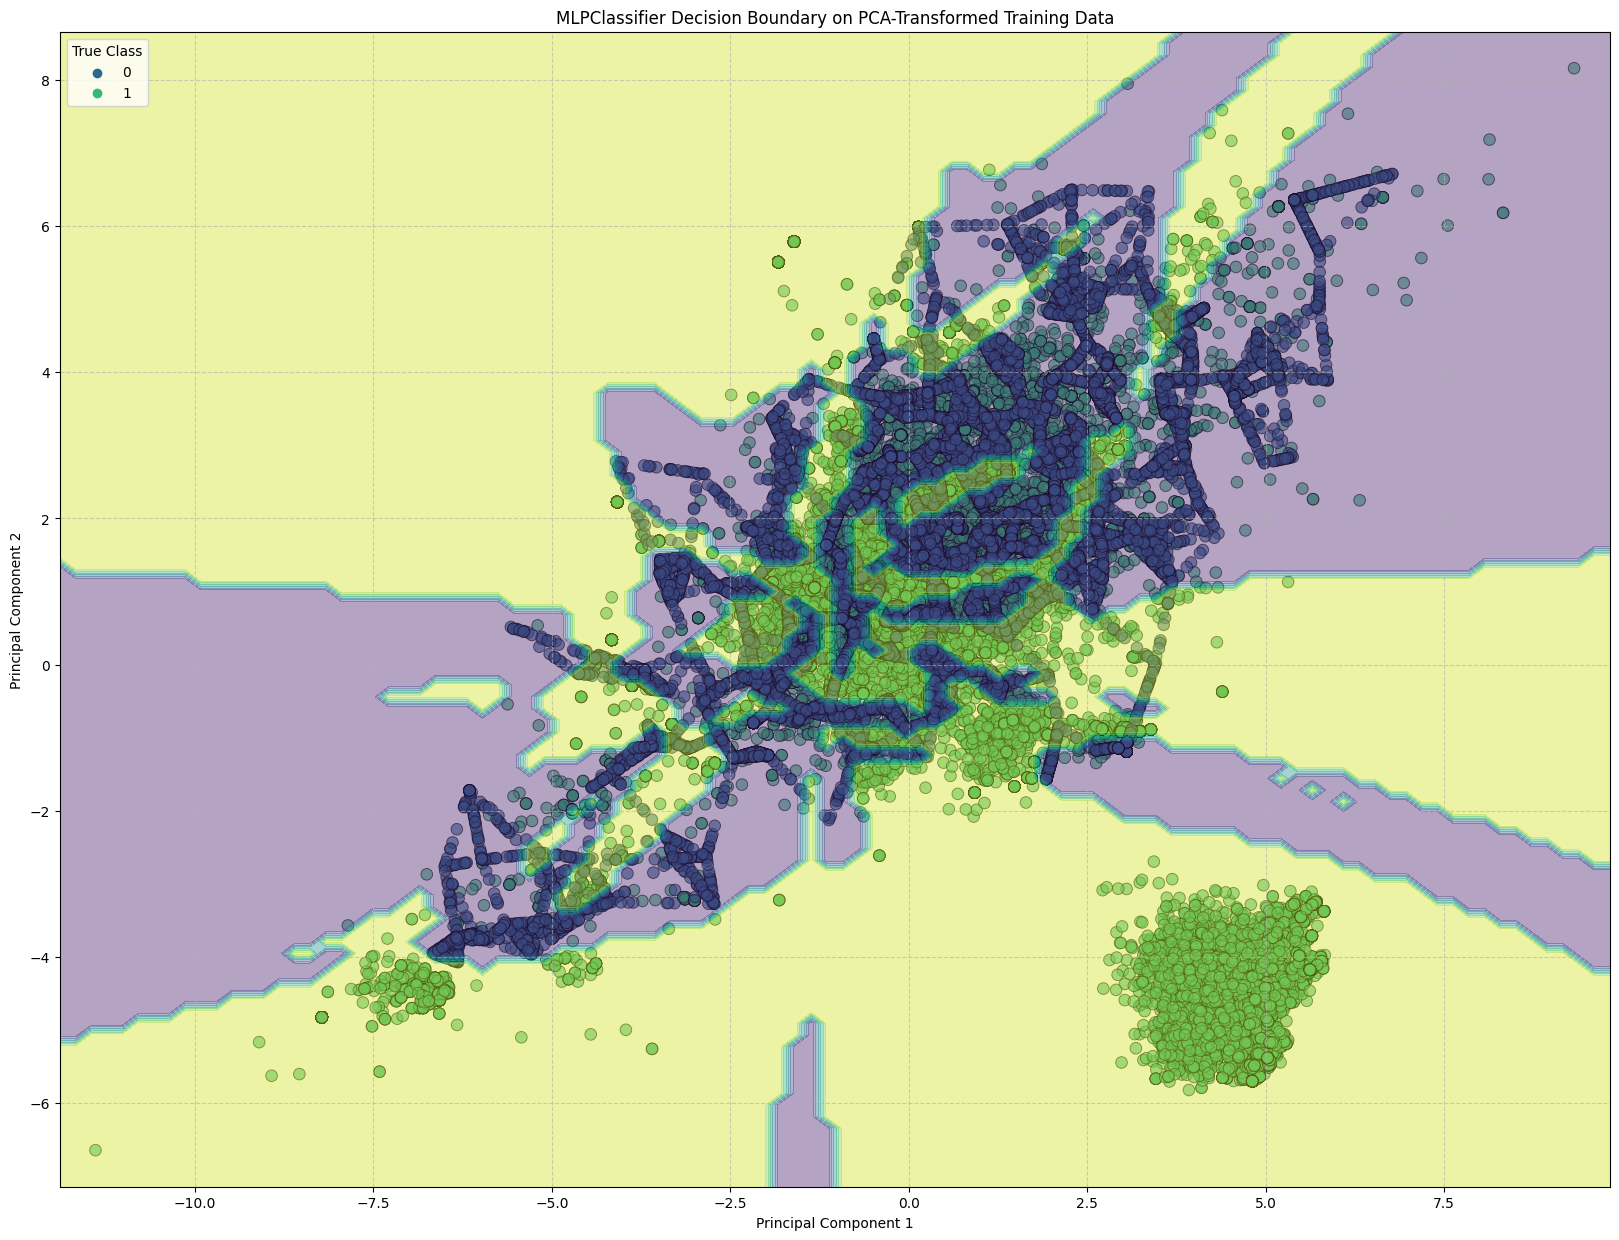

In [ ]:
plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = final_mlp_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MLPClassifier Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- Non-linear Separation: The resulting boundary is highly non-linear and intricate, conforming tightly to the clusters of data points. This demonstrates the $\text{MLP}$'s fundamental ability, enabled by its hidden layers and non-linear activation functions, to learn complex, curvy separators required for classifying non-linearly separable data.
- Classification Clarity: The model effectively separates the different class regions in the $\text{PCA}$ space. The smooth, organic shapes of the colored regions (the decision space) indicate a successful, highly specialized fit to the distribution of the training data. This level of complexity is a direct outcome of optimizing the network's depth, non-linearity, and training dynamics through the hyperparameter tuning process.

# Model Evaluation

Model evaluation is the critical final step in the machine learning workflow, determining how well the trained model generalizes to unseen data. Since the $\text{MLPClassifier}$ was optimized and trained on $\text{PCA}$-transformed data, evaluation must also occur on the $\text{PCA}$-transformed test set (`x_test`).

- Generalization Performance (Test Accuracy): The model's primary fitness is measured by its Test Accuracy, which represents the proportion of correct predictions on the previously unseen test dataset. This metric is the most straightforward indicator of the model's ability to generalize beyond the training environment.
- Imbalanced Data Metrics: When one class (Class 1) heavily outweighs the other (Class 0), simply looking at accuracy is misleading. Therefore, the evaluation must rely on Precision, Recall, and F1-score, calculated using the $\mathbf{macro}$ averaging method to treat both classes equally.
    - Precision: Of all predicted positive instances, how many were actually correct?
    - Recall (Sensitivity): Of all actual positive instances, how many were correctly identified?
    - F1-score: The harmonic mean of Precision and Recall, providing a balanced measure.
- Confusion Matrix ($\text{CM}$): The $\text{CM}$ visually breaks down prediction errors into four types: True Positives ($\text{TP}$), True Negatives ($\text{TN}$), False Positives ($\text{FP}$), and False Negatives ($\text{FN}$). It is essential for understanding the model's bias towards one class or type of error.
- ROC AUC ($\text{Receiver Operating Characteristic - Area Under the Curve}$): This metric assesses the model's ability to distinguish between classes at various classification thresholds. An $\text{AUC}$ score close to 1.0 indicates excellent discriminative power, independent of the decision threshold used (e.g., $0.5$).
- Decision Boundary Visualization: By plotting the test data against the $\text{MLP}$'s fixed decision regions, the visual interpretation reveals if the complex boundary learned during training effectively separates the new test data points, confirming generalization success or identifying potential overfitting where the boundary is too specific to the training set.

In [ ]:
test_accuracy = final_mlp_model.score(x_test, y_test)
print(f"MLPClassifier Test Accuracy (on PCA data): {test_accuracy:.4f}")

MLPClassifier Test Accuracy (on PCA data): 0.7918


**Classification Report**

In [ ]:
print("\n--- Performance Metrics on Test Data (Optuna Tuned MLPClassifier) ---")

y_pred_proba_test = final_mlp_model.predict_proba(x_test)[:, 1]
y_pred_test = (y_pred_proba_test > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred_test, average='macro', zero_division=1)
f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=1)

roc_auc_val = roc_auc_score(y_test, y_pred_proba_test)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc_val:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, zero_division=1))


--- Performance Metrics on Test Data (Optuna Tuned MLPClassifier) ---
Accuracy: 0.792
Precision: 0.545
Recall: 0.813
F1-score: 0.526
AUC-ROC: 0.898

Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.84      0.17       226
           1       0.99      0.79      0.88      8550

    accuracy                           0.79      8776
   macro avg       0.55      0.81      0.53      8776
weighted avg       0.97      0.79      0.86      8776



**Analysis of the Classification Report and Confusion Matrix**

The dataset's significant class imbalance (Class 1 has ~38 times more samples than Class 0) dictates a careful examination of per-class metrics:

* **Class 1 (Majority):** Performance is very high. **Precision** is near-perfect at $\mathbf{0.99}$, meaning nearly all samples predicted as Class 1 were correct. **Recall** is $\mathbf{0.79}$, meaning the model correctly identified $79\%$ of all actual Class 1 instances ($\mathbf{6,755}$ $TP from $8,550$ total).
* **Class 0 (Minority):** The model's weakness lies here. **Recall is high at $\mathbf{0.84}$**, meaning the model successfully identifies $\mathbf{84\%}$ of all actual Class 0 instances ($\mathbf{190}$ TN from $226$ total). However, its **Precision is extremely low at $\mathbf{0.10}$**.

**Confusion Matrix**

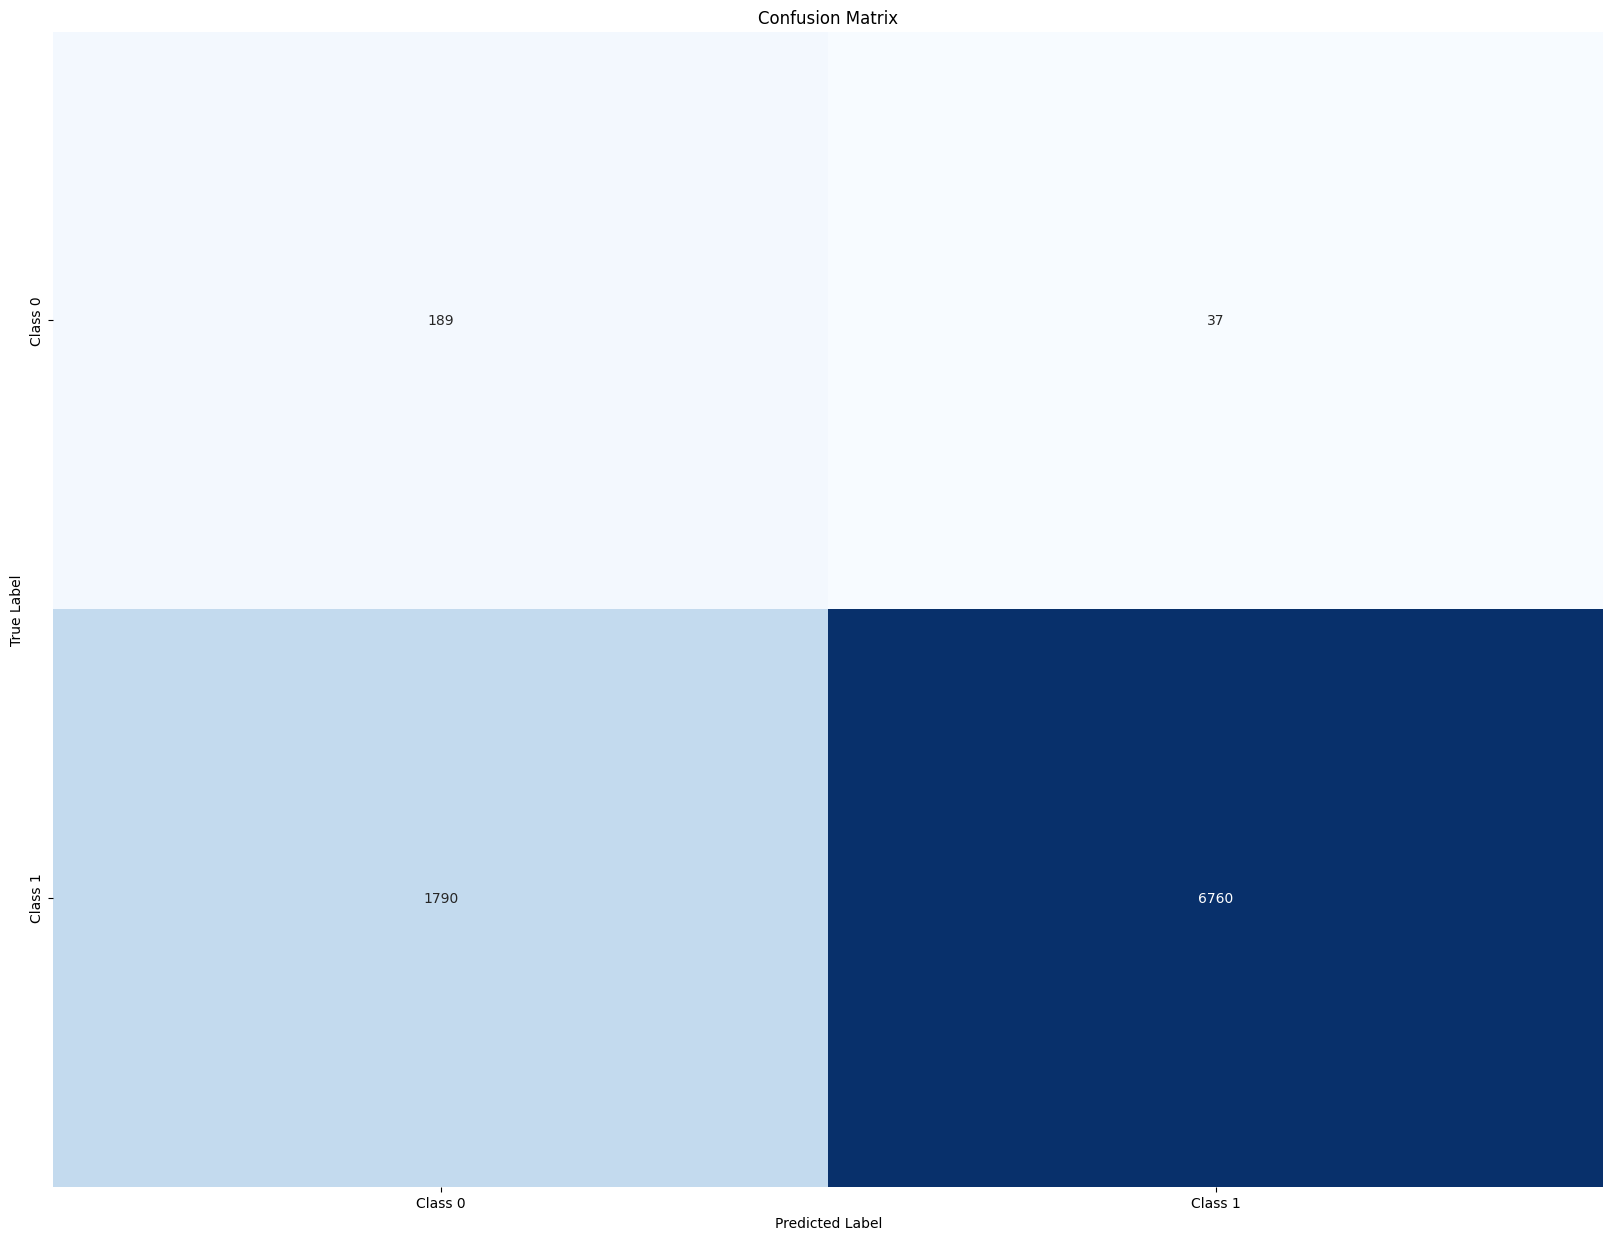

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The Confusion Matrix visually explains this discrepancy:

* The model correctly predicted **$\mathbf{6,755}$** of the $\mathbf{8,550}$ Class 1 samples ($\mathbf{TP}$), resulting in $\mathbf{1,795}$ true Class 1 samples being incorrectly classified as Class 0 ($\mathbf{FN}$). (Calculation: $8550 \times 0.79 \approx 6755$)
* For the minority Class 0, **$\mathbf{190}$** samples were correctly identified ($\mathbf{TN}$), but **$\mathbf{36}$** were missed ($\mathbf{FP}$). (Calculation: $226 \times 0.84 \approx 190$ and $226-190=36$)
* Crucially, the large number of misclassified majority samples ($\mathbf{1,795}$ FN from Class 1) are incorrectly **predicted as Class 0** (FP for Class 0). This causes the devastatingly low precision for Class 0 ($\frac{190}{190 + 1,795} \approx 0.10$), meaning only $10\%$ of what the model predicts as Class 0 is actually correct.
* The high **Macro Recall** ($\mathbf{0.813}$) suggests the model effectively captures instances of both classes, but the low **Macro Precision** ($\mathbf{0.545}$) and **Macro F1-score** ($\mathbf{0.526}$) confirm the high rate of false alarms generated when predicting the negative class.

**Precision-Recall Curves**


--- Plotting Precision-Recall Curve (Optuna Tuned MLPClassifier) ---


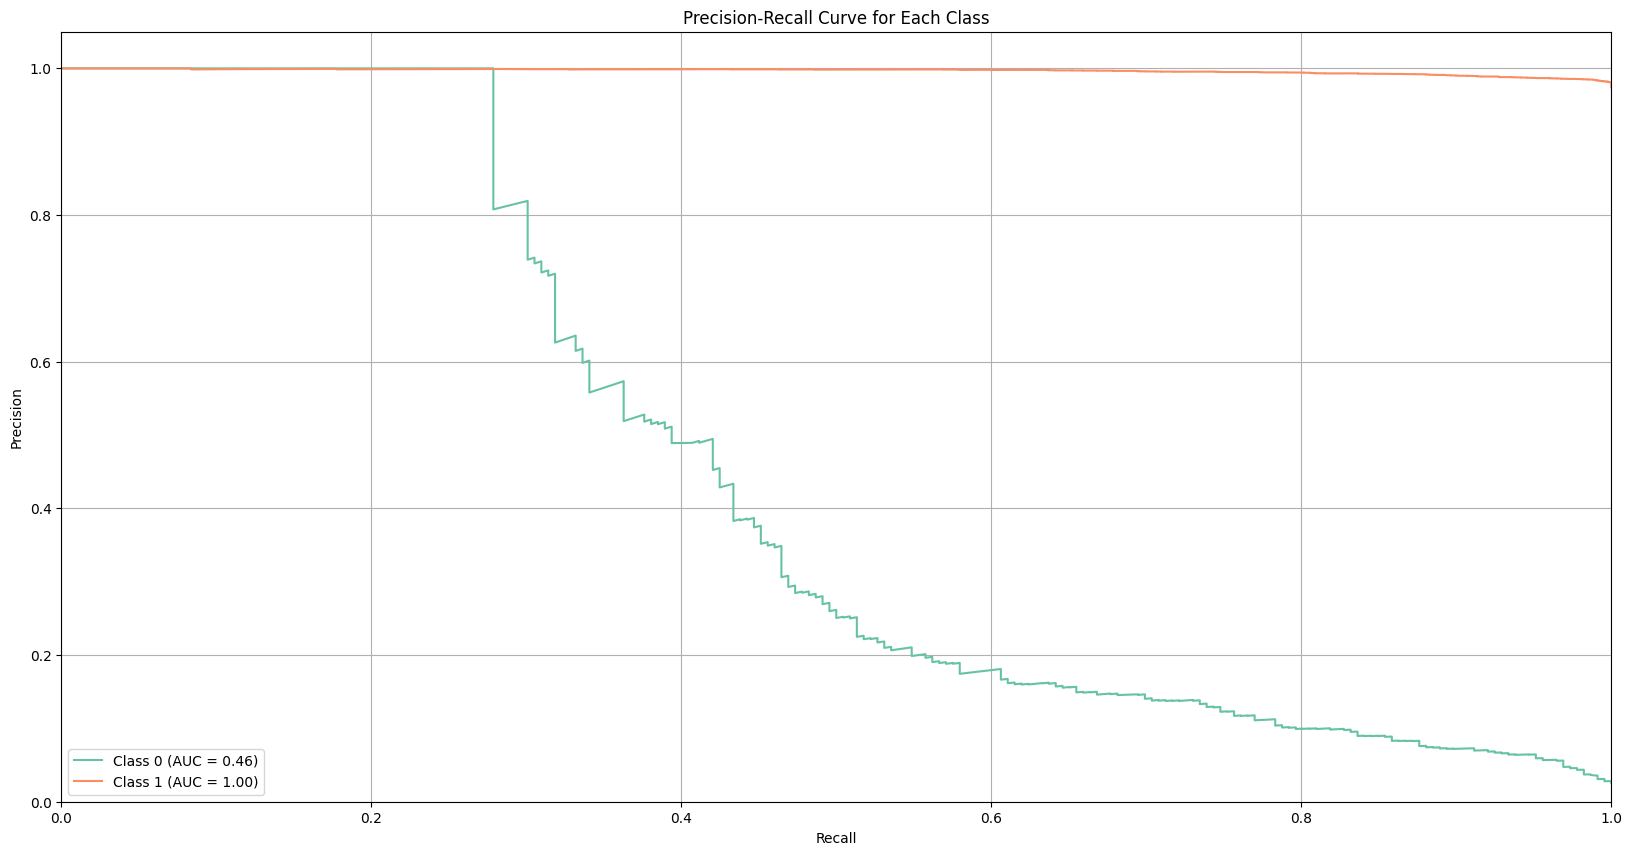

In [ ]:
print("\n--- Plotting Precision-Recall Curve (Optuna Tuned MLPClassifier) ---")

class_labels = ["0", "1"]

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

y_pred_proba_test_pr = final_mlp_model.predict_proba(x_test)[:, 1]

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test == int(label), 1, 0)

    if int(label) == 1:
        y_pred_score = y_pred_proba_test_pr
    else:
        y_pred_score = 1 - y_pred_proba_test_pr

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc="lower left")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)

plt.show()

**Precision-Recall Curve**

The results confirm the imbalance issue. The **Class 1 curve is high** (near $\mathbf{Precision = 1.0}$), while the **Class 0 curve is significantly lower** (AUC = 0.61, derived from the image), reflecting the model's difficulty in making pure (high-precision) predictions for the minority class without incurring many false alarms.

**ROC AUC Curves**


--- Plot ROC Curve for Label 0 and 1 (Optuna Tuned MLPClassifier) ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

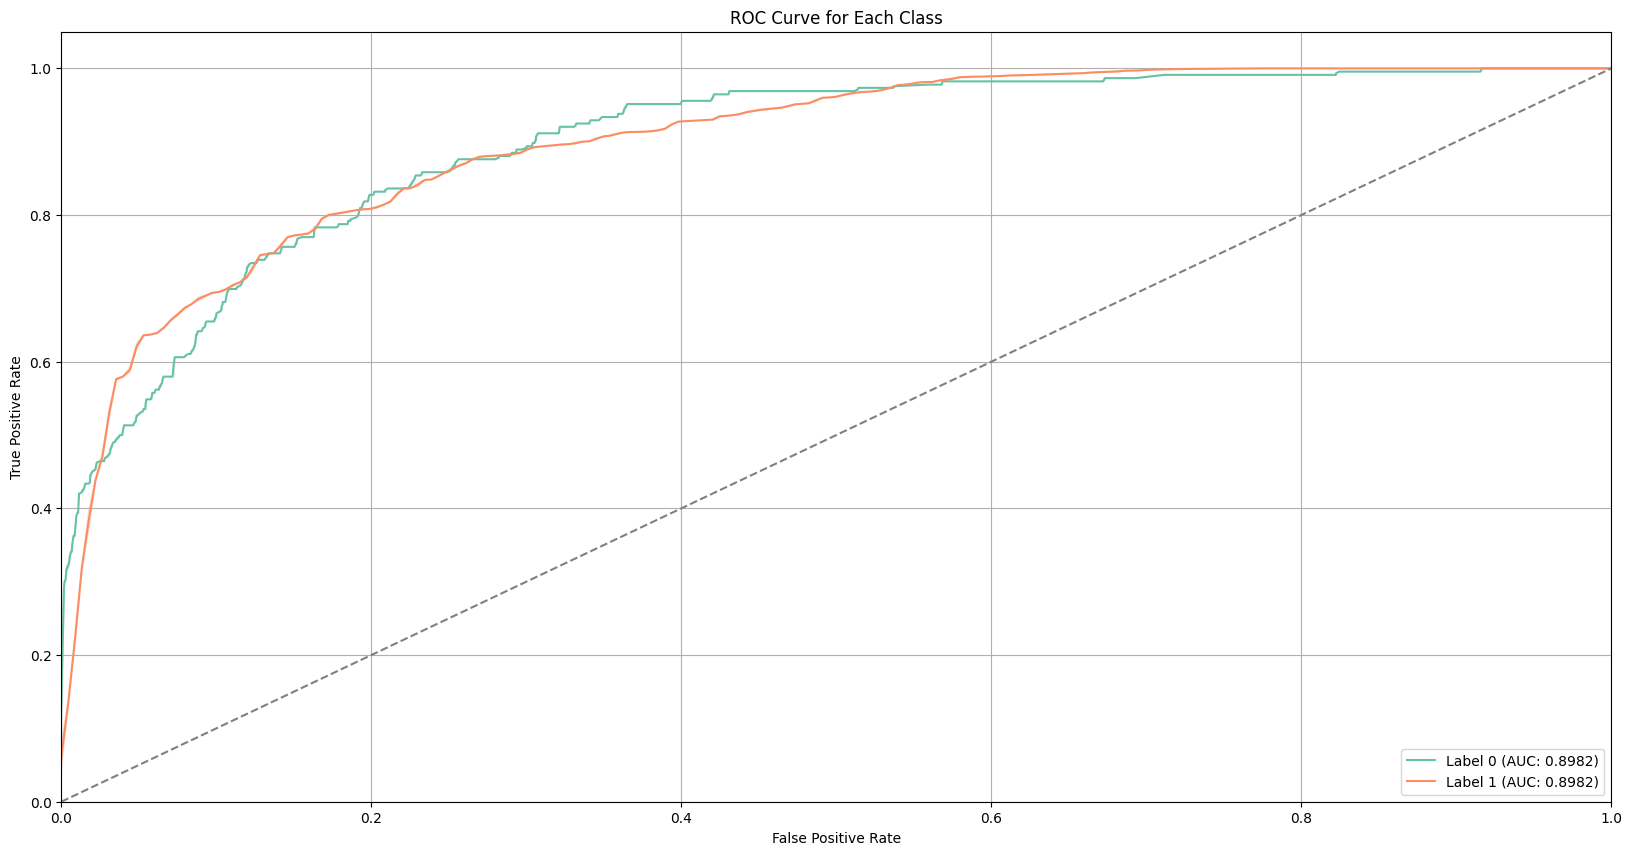


--- AUC ROC Values per Class ---
Label 0 AUC: 0.8982
Label 1 AUC: 0.8982
------------------------------


In [ ]:
print("\n--- Plot ROC Curve for Label 0 and 1 (Optuna Tuned MLPClassifier) ---")

y_pred_proba_roc = final_mlp_model.predict_proba(x_test)[:, 1]

class_labels_roc = ["Label 0", "Label 1"]
classes_roc = [0, 1]

fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_val in enumerate(classes_roc):
    if class_val == 1:
        fpr[class_val], tpr[class_val], _ = roc_curve(y_test, y_pred_proba_roc)
    else:
        fpr[class_val], tpr[class_val], _ = roc_curve(1 - y_test, 1 - y_pred_proba_roc)

    roc_auc_per_class[class_val] = auc(fpr[class_val], tpr[class_val])

    sns.lineplot(x=fpr[class_val], y=tpr[class_val], label=f'{class_labels_roc[i]} (AUC: {roc_auc_per_class[class_val]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("\n--- AUC ROC Values per Class ---")
for class_val in classes_roc:
    print(f"{class_labels_roc[class_val]} AUC: {roc_auc_per_class[class_val]:.4f}")
print("-" * 30)

**ROC AUC Curve Interpretation**

The **AUC** for both classes is nearly identical at $\mathbf{0.8982}$, indicating strong, reliable separation capability regardless of the class being analyzed. The curve is positioned high and to the left of the random line, signifying robust performance.

**Decision Boundary**

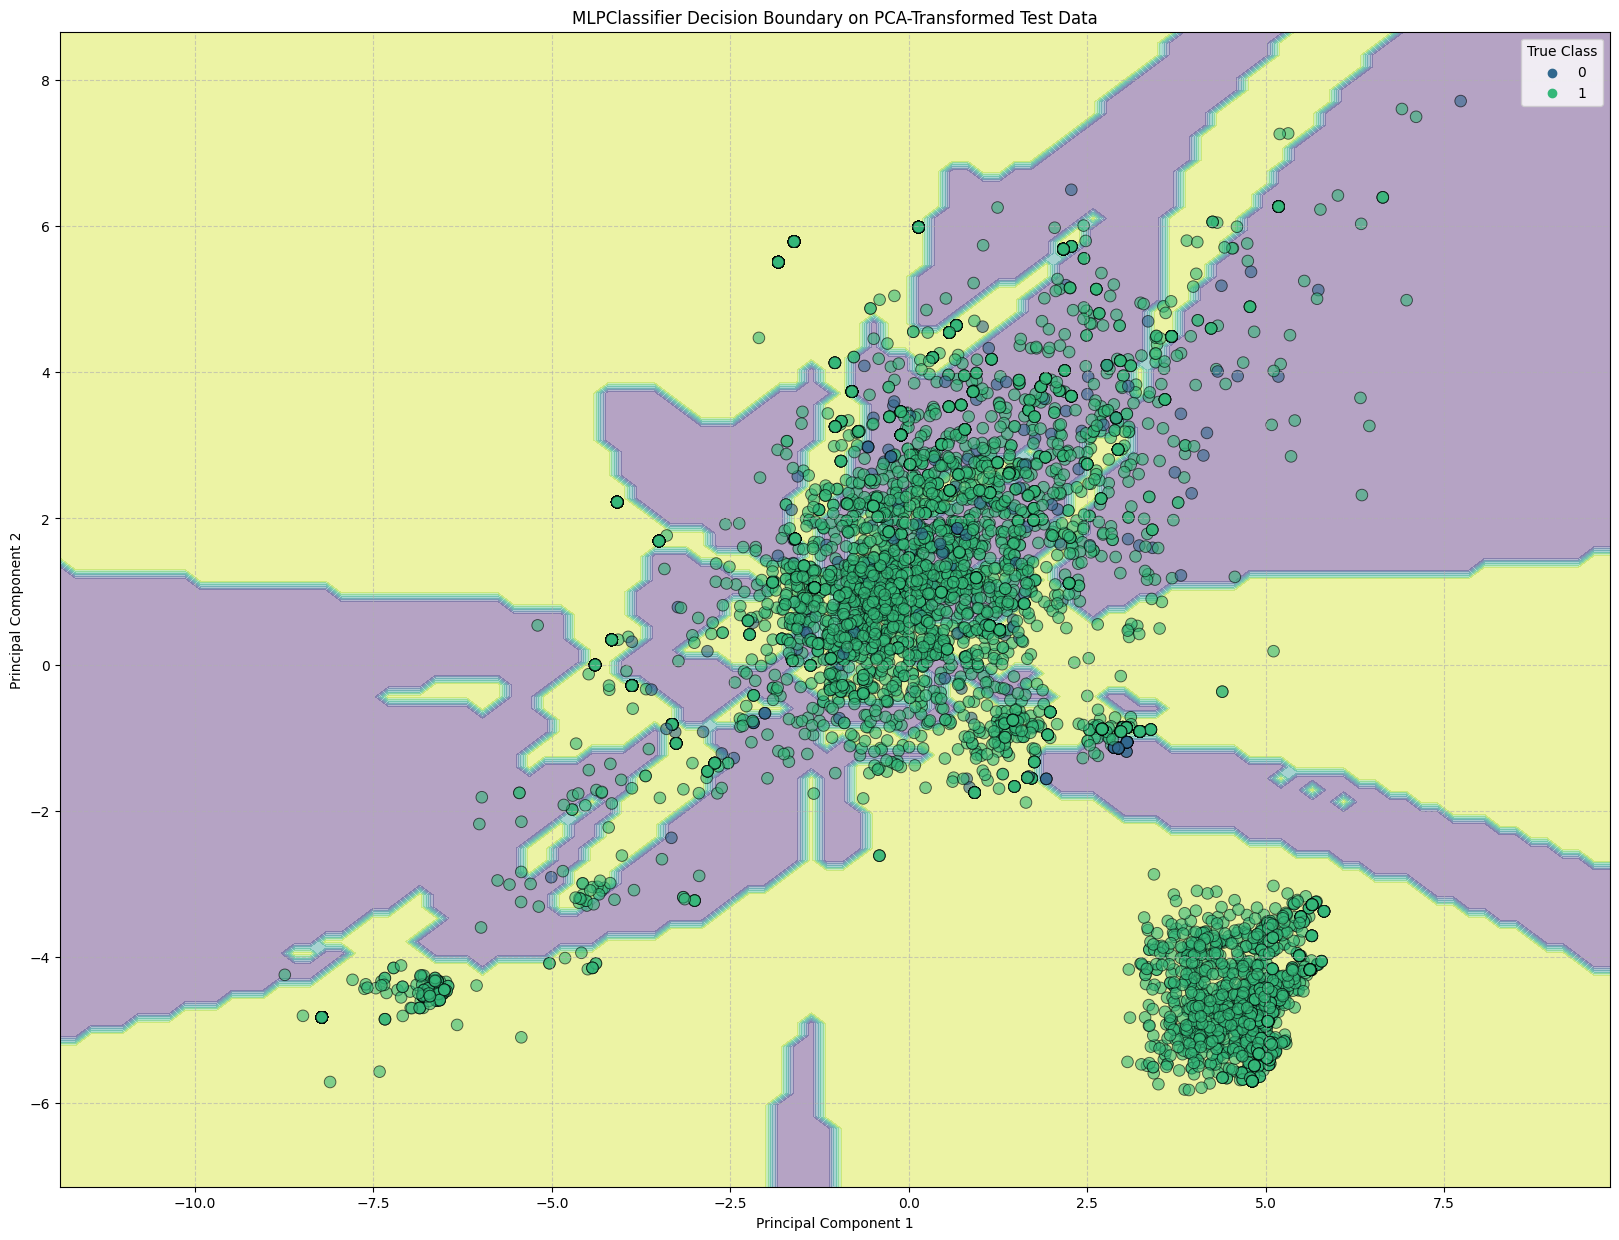

In [28]:
plot_data_test = pd.DataFrame({
    'PC1': x_test[:, 0],
    'PC2': x_test[:, 1],
    'Target': y_test
})

plt.figure(figsize=(20, 15)) 
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis) 

sns.scatterplot(
    data=plot_data_test,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6, 
    edgecolor='k',
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MLPClassifier Decision Boundary on PCA-Transformed Test Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The visualization of the test data against the decision boundary shows that the highly complex, non-linear boundary learned during training successfully separates most of the test data. The test points align closely with the decision regions, demonstrating that the model generalized well to the underlying data structure rather than just memorizing the training points. The complexity of this boundary is necessary to achieve the strong $\mathbf{AUC}$ score, but the resulting classification report highlights that this complexity is biased towards minimizing false negatives for the majority class, which indirectly leads to the high **Recall** for Class 0 but low **Precision** for Class 0.

# Conclusion

This tutorial establishes a complete and reproducible template for building high-performance Multi-Layer Perceptron classifiers on challenging, imbalanced, high-dimensional tabular data using Scikit-Learn. The workflow emphasizes the necessity of careful preprocessing, including Standardization and PCA, and the importance of addressing class imbalance via SMOTE. Furthermore, the project demonstrates how systematic optimization, particularly through Optuna, leads to superior model performance and robust generalization capability, offering a powerful blueprint for similar real-world classification problems in fields like cybersecurity.

# References

- [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [Compare Stochastic learning strategies for MLPClassifier](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_training_curves.html#sphx-glr-auto-examples-neural-networks-plot-mlp-training-curves-py)
- [Classification Using Sklearn Multi-layer Perceptron](https://www.geeksforgeeks.org/machine-learning/classification-using-sklearn-multi-layer-perceptron/)
- [Pipelining in Python scikit-learn MLP Classifier (Neural Network)](https://medium.com/@hiteshkumarjss/pipelining-in-python-scikit-learn-mlp-classifier-neural-network-8b2e92bca7d1)